# Observations

This experiment is trying to find the difference of L2 learning between distributional learning (implemented as reconstruction task) and feedbacked learning (implemented as classification task). There are 4 conditions: RCRC_FZ, RCRC_NFZ, RCCL_FZ, RCCL_NFZ. All conditions has RC first becuase when learning L1 infants receive relatively low amount of feedback. RCRC -> reconstruction as learning goal for L2 as well, RCCL -> switching to classification when leanring L2. FZ means freezing several layers in the encoder during L2 learning (no matter recon or classification, we explicitly divide the model into encoder and decoder/classifier). NFZ means no freezing during L2 learning.  

In [6]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

In [7]:
# plot for each condition
CONDITIONS_MAP = {
    "RCRC_FZ": "Recon Freeze", 
    "RCCL_FZ": "Class Freeze",
    "RCRC_NFZ": "Recon No Freeze",
    "RCCL_NFZ": "Class No Freeze"
}
BASE_PATH = "./observations/"
EPOCH_START = 10
EPOCH_END = 200
EVAL_METHOD = "silhouette"
RUNS = [3, 4, 5, 6, 7, 8]

class TYPE_NAME: 
    SAME = "Same"
    CONT = "Cont"
    POA = "POA"
    CONTPOA = "Cont + POA"
    ASP = "Aspiration"
    POAASP = "POA + Aspiration"
    CONTASP = "Cont + Aspiration"
    ALL = "All"

    SAME_L1 = "Same L1"
    SAME_L2 = "Same L2"
    CONT_L1 = "Cont L1"
    CONT_L2 = "Cont L2"
    POA_L1 = "POA L1"
    POA_L2 = "POA L2"
    CONTPOA_L1 = "Cont + POA L1"
    CONTPOA_L2 = "Cont + POA L2"
    OTHER = "Other Contrasts"

class L_NAME: 
    L1 = "L1"
    L2 = "L2"
    NA = "NA"

TYPE_MAP = {
    "ts_ts": TYPE_NAME.SAME, "tc_tc": TYPE_NAME.SAME, "s_s": TYPE_NAME.SAME, "c_c": TYPE_NAME.SAME, "tsh_tsh": TYPE_NAME.SAME, "tch_tch": TYPE_NAME.SAME, "sh_sh": TYPE_NAME.SAME, "ch_ch": TYPE_NAME.SAME,

    "ts_tc": TYPE_NAME.POA, "tc_ts": TYPE_NAME.POA, "s_c": TYPE_NAME.POA, "c_s": TYPE_NAME.POA, "tsh_tch": TYPE_NAME.POA, "tch_tsh": TYPE_NAME.POA, "sh_ch": TYPE_NAME.POA, "ch_sh": TYPE_NAME.POA,

    "ts_s": TYPE_NAME.CONT, "s_ts": TYPE_NAME.CONT, "tc_c": TYPE_NAME.CONT, "c_tc": TYPE_NAME.CONT, "tsh_sh": TYPE_NAME.CONT, "sh_tsh": TYPE_NAME.CONT, "tch_ch": TYPE_NAME.CONT, "ch_tch": TYPE_NAME.CONT,

    "ts_c": TYPE_NAME.CONTPOA, "c_ts": TYPE_NAME.CONTPOA, "tc_s": TYPE_NAME.CONTPOA, "s_tc": TYPE_NAME.CONTPOA, "tsh_ch": TYPE_NAME.CONTPOA, "ch_tsh": TYPE_NAME.CONTPOA, "tch_sh": TYPE_NAME.CONTPOA, "sh_tch": TYPE_NAME.CONTPOA,

    "ts_tsh": TYPE_NAME.ASP, "tsh_ts": TYPE_NAME.ASP, "tc_tch": TYPE_NAME.ASP, "tch_tc": TYPE_NAME.ASP, "s_sh": TYPE_NAME.ASP, "sh_s": TYPE_NAME.ASP, "c_ch": TYPE_NAME.ASP, "ch_c": TYPE_NAME.ASP, 

    "tsh_tc": TYPE_NAME.POAASP, "tc_tsh": TYPE_NAME.POAASP, "tch_ts": TYPE_NAME.POAASP, "ts_tch": TYPE_NAME.POAASP, "sh_c": TYPE_NAME.POAASP, "c_sh": TYPE_NAME.POAASP, "ch_s": TYPE_NAME.POAASP, "s_ch": TYPE_NAME.POAASP,

    "ts_sh": TYPE_NAME.CONTASP, "sh_ts": TYPE_NAME.CONTASP, "tc_ch": TYPE_NAME.CONTASP, "ch_tc": TYPE_NAME.CONTASP, "tsh_s": TYPE_NAME.CONTASP, "s_tsh": TYPE_NAME.CONTASP, "tch_c": TYPE_NAME.CONTASP, "c_tch": TYPE_NAME.CONTASP,

    "s_tch": TYPE_NAME.ALL, "tch_s": TYPE_NAME.ALL, "tsh_c": TYPE_NAME.ALL, "c_tsh": TYPE_NAME.ALL, "sh_tc": TYPE_NAME.ALL, "tc_sh": TYPE_NAME.ALL, "ch_ts": TYPE_NAME.ALL, "ts_ch": TYPE_NAME.ALL
}

TYPE_MAP_L1L2 = {
    "ts_ts": TYPE_NAME.SAME_L1, "tc_tc": TYPE_NAME.SAME_L1, "s_s": TYPE_NAME.SAME_L1, "c_c": TYPE_NAME.SAME_L1, 
    "tsh_tsh": TYPE_NAME.SAME_L2, "tch_tch": TYPE_NAME.SAME_L2, "sh_sh": TYPE_NAME.SAME_L2, "ch_ch": TYPE_NAME.SAME_L2,

    "ts_tc": TYPE_NAME.POA_L1, "tc_ts": TYPE_NAME.POA_L1, "s_c": TYPE_NAME.POA_L1, "c_s": TYPE_NAME.POA_L1, 
    "tsh_tch": TYPE_NAME.POA_L2, "tch_tsh": TYPE_NAME.POA_L2, "sh_ch": TYPE_NAME.POA_L2, "ch_sh": TYPE_NAME.POA_L2,

    "ts_s": TYPE_NAME.CONT_L1, "s_ts": TYPE_NAME.CONT_L1, "tc_c": TYPE_NAME.CONT_L1, "c_tc": TYPE_NAME.CONT_L1, 
    "tsh_sh": TYPE_NAME.CONT_L2, "sh_tsh": TYPE_NAME.CONT_L2, "tch_ch": TYPE_NAME.CONT_L2, "ch_tch": TYPE_NAME.CONT_L2,

    "ts_c": TYPE_NAME.CONTPOA_L1, "c_ts": TYPE_NAME.CONTPOA_L1, "tc_s": TYPE_NAME.CONTPOA_L1, "s_tc": TYPE_NAME.CONTPOA_L1, 
    "tsh_ch": TYPE_NAME.CONTPOA_L2, "ch_tsh": TYPE_NAME.CONTPOA_L2, "tch_sh": TYPE_NAME.CONTPOA_L2, "sh_tch": TYPE_NAME.CONTPOA_L2,

    "ts_tsh": TYPE_NAME.ASP, "tsh_ts": TYPE_NAME.ASP, "tc_tch": TYPE_NAME.ASP, "tch_tc": TYPE_NAME.ASP, "s_sh": TYPE_NAME.ASP, "sh_s": TYPE_NAME.ASP, "c_ch": TYPE_NAME.ASP, "ch_c": TYPE_NAME.ASP, 

    "tsh_tc": TYPE_NAME.OTHER, "tc_tsh": TYPE_NAME.OTHER, "tch_ts": TYPE_NAME.OTHER, "ts_tch": TYPE_NAME.OTHER, "sh_c": TYPE_NAME.OTHER, "c_sh": TYPE_NAME.OTHER, "ch_s": TYPE_NAME.OTHER, "s_ch": TYPE_NAME.OTHER,

    "ts_sh": TYPE_NAME.OTHER, "sh_ts": TYPE_NAME.OTHER, "tc_ch": TYPE_NAME.OTHER, "ch_tc": TYPE_NAME.OTHER, "tsh_s": TYPE_NAME.OTHER, "s_tsh": TYPE_NAME.OTHER, "tch_c": TYPE_NAME.OTHER, "c_tch": TYPE_NAME.OTHER,

    "s_tch": TYPE_NAME.OTHER, "tch_s": TYPE_NAME.OTHER, "tsh_c": TYPE_NAME.OTHER, "c_tsh": TYPE_NAME.OTHER, "sh_tc": TYPE_NAME.OTHER, "tc_sh": TYPE_NAME.OTHER, "ch_ts": TYPE_NAME.OTHER, "ts_ch": TYPE_NAME.OTHER
}

L_MAP = {
    "ts_ts": L_NAME.L1, "tc_tc": L_NAME.L1, "s_s": L_NAME.L1, "c_c": L_NAME.L1, 
    "tsh_tsh": L_NAME.L2, "tch_tch": L_NAME.L2, "sh_sh": L_NAME.L2, "ch_ch": L_NAME.L2,

    "ts_tc": L_NAME.L1, "tc_ts": L_NAME.L1, "s_c": L_NAME.L1, "c_s": L_NAME.L1, 
    "tsh_tch": L_NAME.L2, "tch_tsh": L_NAME.L2, "sh_ch": L_NAME.L2, "ch_sh": L_NAME.L2,

    "ts_s": L_NAME.L1, "s_ts": L_NAME.L1, "tc_c": L_NAME.L1, "c_tc": L_NAME.L1, 
    "tsh_sh": L_NAME.L2, "sh_tsh": L_NAME.L2, "tch_ch": L_NAME.L2, "ch_tch": L_NAME.L2,

    "ts_c": L_NAME.L1, "c_ts": L_NAME.L1, "tc_s": L_NAME.L1, "s_tc": L_NAME.L1, 
    "tsh_ch": L_NAME.L2, "ch_tsh": L_NAME.L2, "tch_sh": L_NAME.L2, "sh_tch": L_NAME.L2,

    "ts_tsh": L_NAME.NA, "tsh_ts": L_NAME.NA, "tc_tch": L_NAME.NA, "tch_tc": L_NAME.NA, 
    "s_sh": L_NAME.NA, "sh_s": L_NAME.NA, "c_ch": L_NAME.NA, "ch_c": L_NAME.NA, 

    "tsh_tc": L_NAME.NA, "tc_tsh": L_NAME.NA, "tch_ts": L_NAME.NA, "ts_tch": L_NAME.NA, 
    "sh_c": L_NAME.NA, "c_sh": L_NAME.NA, "ch_s": L_NAME.NA, "s_ch": L_NAME.NA,

    "ts_sh": L_NAME.NA, "sh_ts": L_NAME.NA, "tc_ch": L_NAME.NA, "ch_tc": L_NAME.NA, 
    "tsh_s": L_NAME.NA, "s_tsh": L_NAME.NA, "tch_c": L_NAME.NA, "c_tch": L_NAME.NA,

    "s_tch": L_NAME.NA, "tch_s": L_NAME.NA, "tsh_c": L_NAME.NA, "c_tsh": L_NAME.NA, 
    "sh_tc": L_NAME.NA, "tc_sh": L_NAME.NA, "ch_ts": L_NAME.NA, "ts_ch": L_NAME.NA
}

collected_results = {}

for condition, label in CONDITIONS_MAP.items(): 
    condition_path = BASE_PATH + condition + "/"
    integrated_df = pd.DataFrame()
    for epoch in range(EPOCH_START, EPOCH_END + 1, 10): 
        for run in RUNS:    # currently only one run, but we want to average over multiple runs if existing
            file_path = condition_path + f"{EVAL_METHOD}_E{epoch}_R{run}.csv"
            df = pd.read_csv(file_path)
            # Process the dataframe here
            # print(f"Condition: {label}, Epoch: {epoch}, Run: {run}")
            
            scores = df["sil_score"].tolist()
            types = [TYPE_MAP[t] for t in df["sil_type"].tolist()]
            languages = [L_MAP[t] for t in df["sil_type"].tolist()]
            # types = [t for t in df["sil_type"].tolist()]

            result_df = pd.DataFrame({
                "contrast_pair": df["sil_type"].tolist(),
                "eval_type": types,
                "eval_lang": languages,
                "sil_score": scores, 
                "run": [run] * len(scores),
                "epoch": [epoch] * len(scores)})
            integrated_df = pd.concat([integrated_df, result_df], ignore_index=True)
    
    collected_results[label] = integrated_df

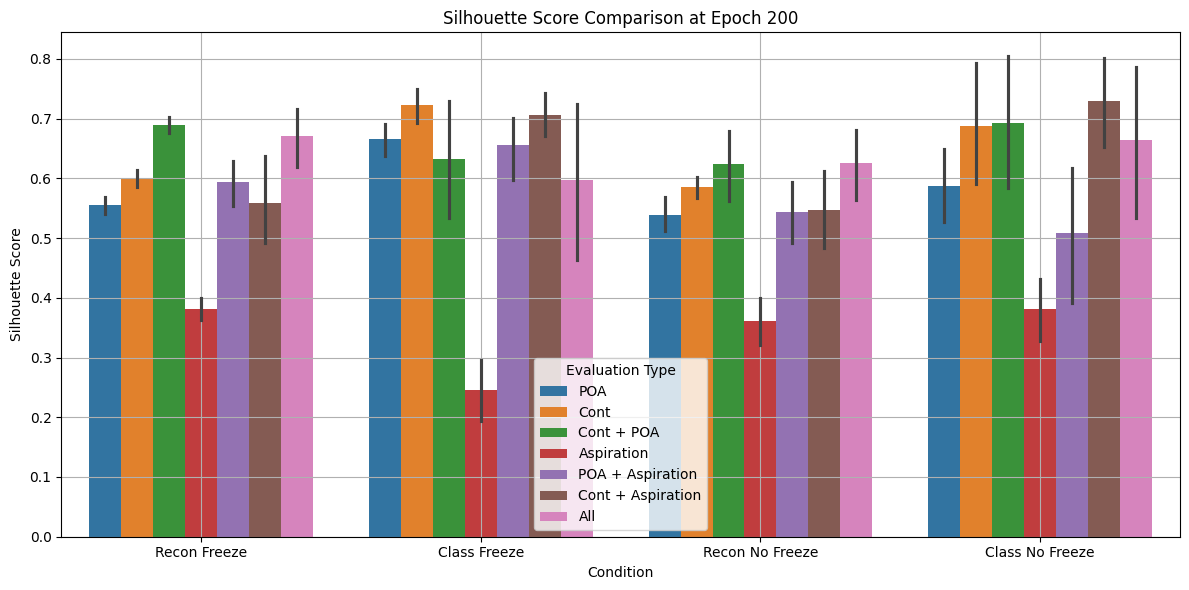

In [8]:
# draw the last epoch comparison across conditions
final_epoch = 200
final_df = pd.DataFrame()
for condition, label in CONDITIONS_MAP.items(): 
    condition_df = collected_results[label]
    epoch_df = condition_df[condition_df["epoch"] == final_epoch]
    epoch_df = epoch_df[epoch_df["eval_type"] != TYPE_NAME.SAME]
    epoch_df["condition"] = [label] * len(epoch_df)
    final_df = pd.concat([final_df, epoch_df], ignore_index=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=final_df, x="condition", y="sil_score", hue="eval_type", errorbar=("ci", 95))
plt.title(f"Silhouette Score Comparison at Epoch {final_epoch}")
plt.xlabel("Condition")
plt.ylabel("Silhouette Score")
plt.legend(title="Evaluation Type")
plt.grid(True)
plt.tight_layout()
plt.show()

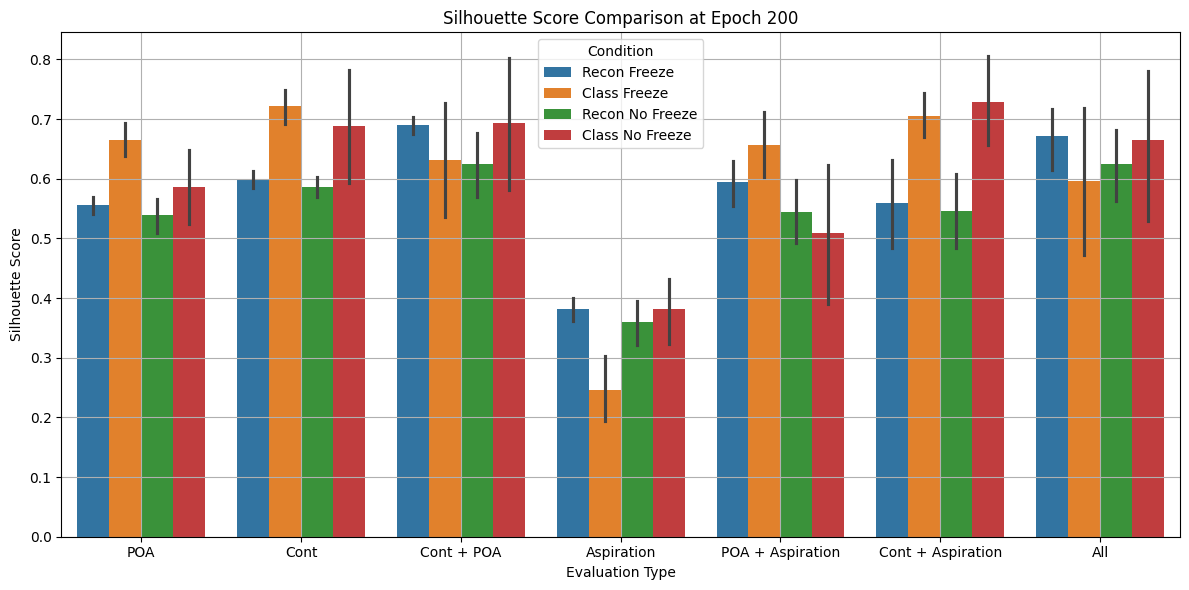

In [9]:
# draw the last epoch comparison across conditions, organize first by eval type then by condition
final_epoch = 200
final_df = pd.DataFrame()
for condition, label in CONDITIONS_MAP.items(): 
    condition_df = collected_results[label]
    epoch_df = condition_df[condition_df["epoch"] == final_epoch]
    epoch_df = epoch_df[~epoch_df["eval_type"].isin([TYPE_NAME.SAME, TYPE_NAME.SAME_L1, TYPE_NAME.SAME_L2])]
    epoch_df["condition"] = [label] * len(epoch_df)
    final_df = pd.concat([final_df, epoch_df], ignore_index=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=final_df, x="eval_type", y="sil_score", hue="condition", errorbar=("ci", 95))
plt.title(f"Silhouette Score Comparison at Epoch {final_epoch}")
plt.xlabel("Evaluation Type")
plt.ylabel("Silhouette Score")
plt.legend(title="Condition")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# make four conditions into one df, with Recon/Class and Freeze/NoFreeze as columns
collected_results_combined = pd.DataFrame()
for condition, label in CONDITIONS_MAP.items():
    condition_df = collected_results[label]
    condition_df["recon_class"] = "Recon" if "RCRC" in condition else "Class"
    condition_df["freeze"] = "NoFreeze" if "NFZ" in condition else "Freeze"
    condition_df["condition"] = [label] * len(condition_df)
    collected_results_combined = pd.concat([collected_results_combined, condition_df], ignore_index=True)

# make eval_type into contrast and L1L2


In [12]:
collected_results_combined

,contrast_pair,eval_type,eval_lang,sil_score,run,epoch,recon_class,freeze,condition
0,tsh_tsh,Same,L2,-0.000065,3,10,Recon,Freeze,Recon Freeze
1,tsh_tch,POA,L2,0.644507,3,10,Recon,Freeze,Recon Freeze
2,tsh_sh,Cont,L2,0.686110,3,10,Recon,Freeze,Recon Freeze
3,tsh_ch,Cont + POA,L2,0.782827,3,10,Recon,Freeze,Recon Freeze
4,tsh_ts,Aspiration,NA,0.454397,3,10,Recon,Freeze,Recon Freeze
...,...,...,...,...,...,...,...,...,...
17275,tc_s,Cont + POA,L1,0.248952,8,200,Class,NoFreeze,Class No Freeze
17276,tc_c,Cont,L1,0.387734,8,200,Class,NoFreeze,Class No Freeze
17277,s_s,Same,L1,0.000009,8,200,Class,NoFreeze,Class No Freeze
17278,s_c,POA,L1,0.847413,8,200,Class,NoFreeze,Class No Freeze


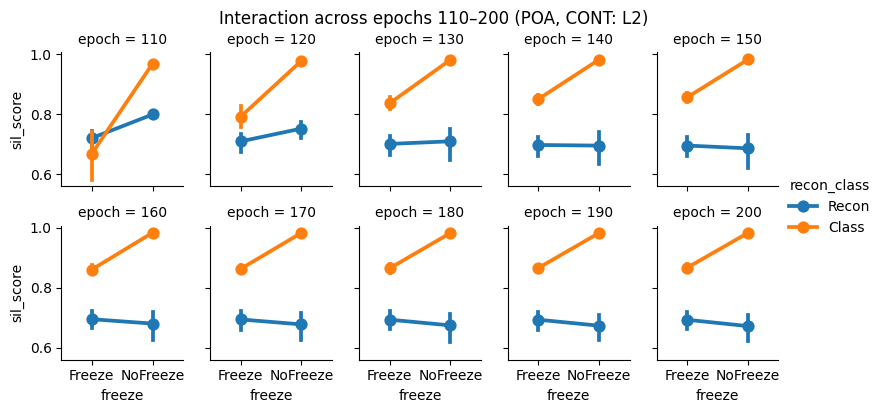

In [13]:
# plot 110 to 200 into one big composed plot
import seaborn as sns
import matplotlib.pyplot as plt
df = collected_results_combined
# df = df[df["eval_type"].isin([TYPE_NAME.CONT, TYPE_NAME.POA])]
df = df[df["contrast_pair"] == "tsh_ch"]
df = df[df["eval_lang"] == L_NAME.L2]
df = df[df["epoch"].between(110, 200)]
g = sns.catplot(
    data=df,
    x="freeze",
    y="sil_score",
    hue="recon_class",
    col="epoch",
    col_wrap=5,
    kind="point",
    ci=95,
    height=2,
    aspect=0.8
)

g.fig.suptitle("Interaction across epochs 110–200 (POA, CONT: L2)", y=1.02)
plt.show()

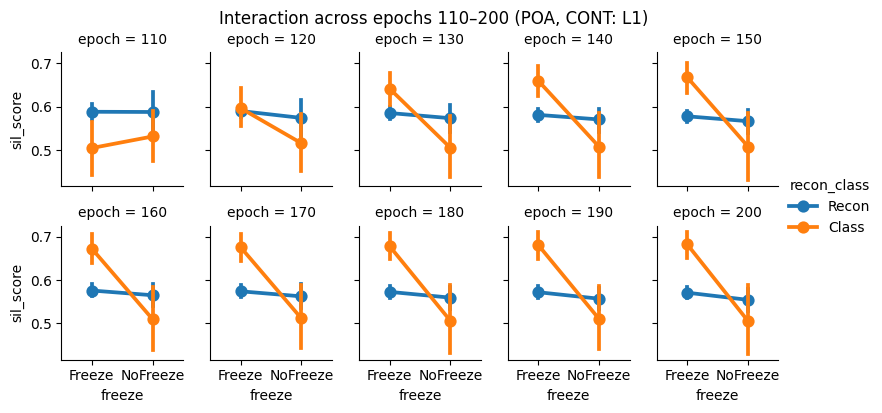

In [15]:
# plot 110 to 200 into one big composed plot
import seaborn as sns
import matplotlib.pyplot as plt
df = collected_results_combined
df = df[df["eval_type"].isin([TYPE_NAME.CONT, TYPE_NAME.POA])]
df = df[df["eval_lang"] == L_NAME.L1]
df = df[df["epoch"].between(110, 200)]
g = sns.catplot(
    data=df,
    x="freeze",
    y="sil_score",
    hue="recon_class",
    col="epoch",
    col_wrap=5,
    kind="point",
    ci=95,
    height=2,
    aspect=0.8
)

g.fig.suptitle("Interaction across epochs 110–200 (POA, CONT: L1)", y=1.02)
plt.show()

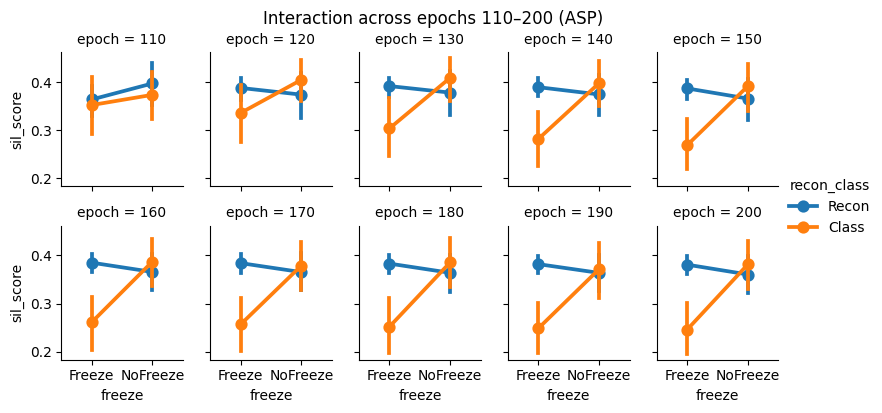

In [16]:
# plot 110 to 200 into one big composed plot
import seaborn as sns
import matplotlib.pyplot as plt
df = collected_results_combined
df = df[df["eval_type"].isin([TYPE_NAME.ASP])]
# df = df[df["eval_lang"] == L_NAME.L2]
df = df[df["epoch"].between(110, 200)]
g = sns.catplot(
    data=df,
    x="freeze",
    y="sil_score",
    hue="recon_class",
    col="epoch",
    col_wrap=5,
    kind="point",
    ci=95,
    height=2,
    aspect=0.8
)

g.fig.suptitle("Interaction across epochs 110–200 (ASP)", y=1.02)
plt.show()

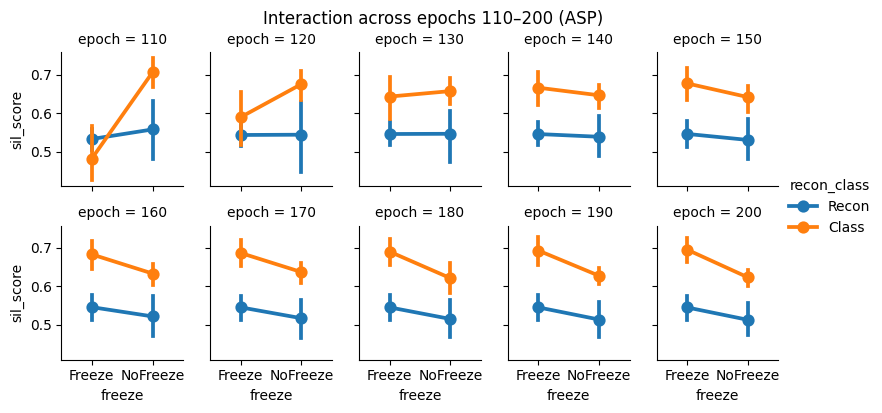

In [34]:
# plot 110 to 200 into one big composed plot
import seaborn as sns
import matplotlib.pyplot as plt
df = collected_results_combined
df = df[df["contrast_pair"].isin(["sh_ch"])]
# df = df[df["eval_lang"] == L_NAME.L2]
df = df[df["epoch"].between(110, 200)]
g = sns.catplot(
    data=df,
    x="freeze",
    y="sil_score",
    hue="recon_class",
    col="epoch",
    col_wrap=5,
    kind="point",
    ci=95,
    height=2,
    aspect=0.8
)

g.fig.suptitle("Interaction across epochs 110–200 (ASP)", y=1.02)
plt.show()

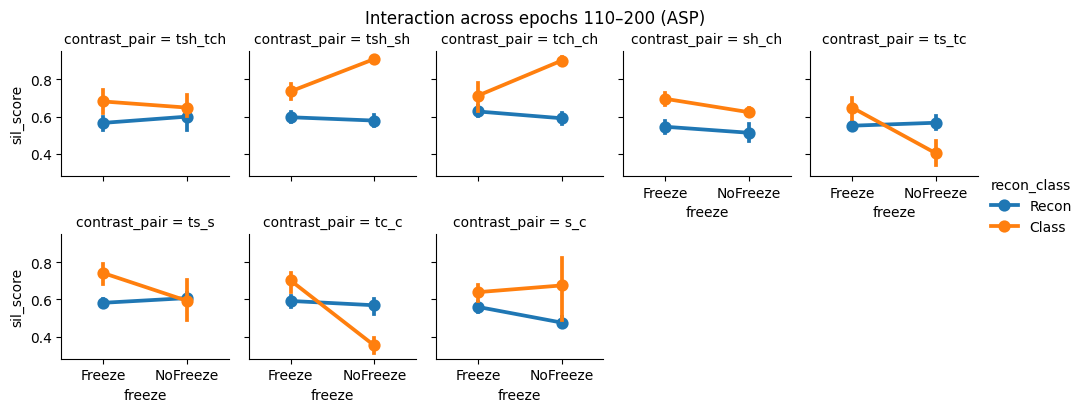

In [40]:
# plot 110 to 200 into one big composed plot
import seaborn as sns
import matplotlib.pyplot as plt
df = collected_results_combined
# df = df[df["contrast_pair"].isin(["sh_ch"])]
# df = df[~df["eval_type"].isin([TYPE_NAME.SAME])]
df = df[df["eval_type"].isin([TYPE_NAME.POA, TYPE_NAME.CONT])]
# df = df[df["eval_lang"] == L_NAME.L2]
df = df[df["epoch"].between(191, 200)]
g = sns.catplot(
    data=df,
    x="freeze",
    y="sil_score",
    hue="recon_class",
    col="contrast_pair",
    col_wrap=5,
    kind="point",
    ci=95,
    height=2,
    aspect=1
)

g.fig.suptitle("Interaction across epochs 110–200 (ASP)", y=1.02)
plt.show()

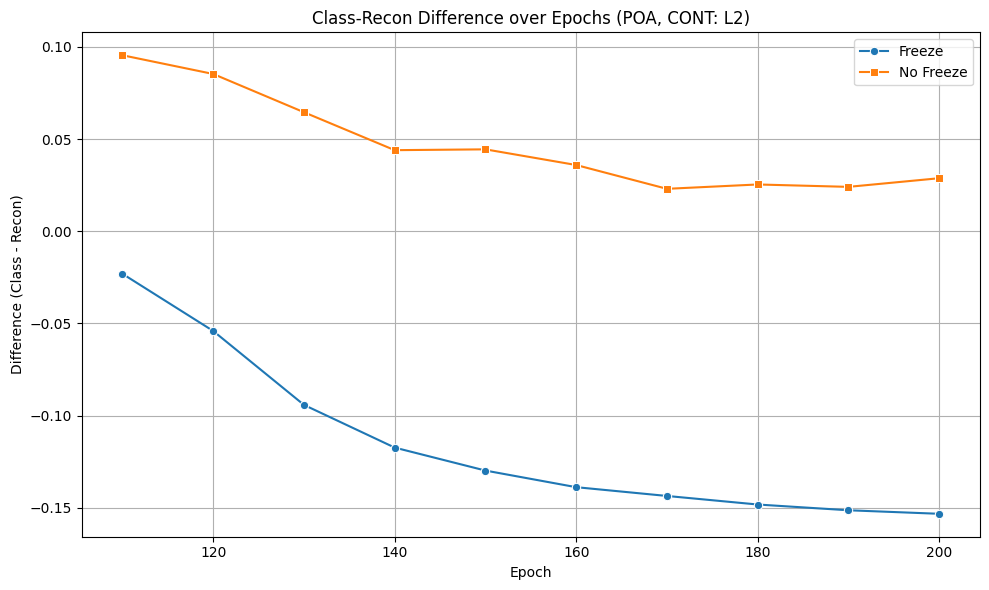

In [27]:
dffindff = []
# draw the epoch-development of the interaction effect
for epoch in range(110, EPOCH_END + 1, 10):
    df_epoch = collected_results_combined
    # df_epoch = df_epoch[df_epoch["eval_type"].isin([TYPE_NAME.CONT, TYPE_NAME.POA])]
    df_epoch = df_epoch[df_epoch["contrast_pair"] == "tsh_ts"]
    # df_epoch = df_epoch[df_epoch["eval_lang"] == L_NAME.L2]
    df_epoch = df_epoch[df_epoch["epoch"] == epoch]
    # predicted marginal means
    means = df_epoch.groupby(["recon_class","freeze"])["sil_score"].mean()
    # print(means)
    # difference of differences
    diff_freeze = (means["Class","Freeze"] - means["Recon","Freeze"])
    diff_nofreeze = (means["Class","NoFreeze"] - means["Recon","NoFreeze"])

    # print("Difference-in-differences:", diff)
    dffindff.append({"epoch": epoch, "diff_freeze": diff_freeze, "diff_nofreeze": diff_nofreeze})

dffindff_df = pd.DataFrame(dffindff)
plt.figure(figsize=(10, 6))
sns.lineplot(data=dffindff_df, x="epoch", y="diff_freeze", marker="o", label="Freeze")
sns.lineplot(data=dffindff_df, x="epoch", y="diff_nofreeze", marker="s", label="No Freeze")
plt.title("Class-Recon Difference over Epochs (POA, CONT: L2)")
plt.xlabel("Epoch")
plt.ylabel("Difference (Class - Recon)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Basic observations on learning trajectory
- the geometry of the training tokens seems to affect the relationship between Class/Recon and Freeze/NoFreeze

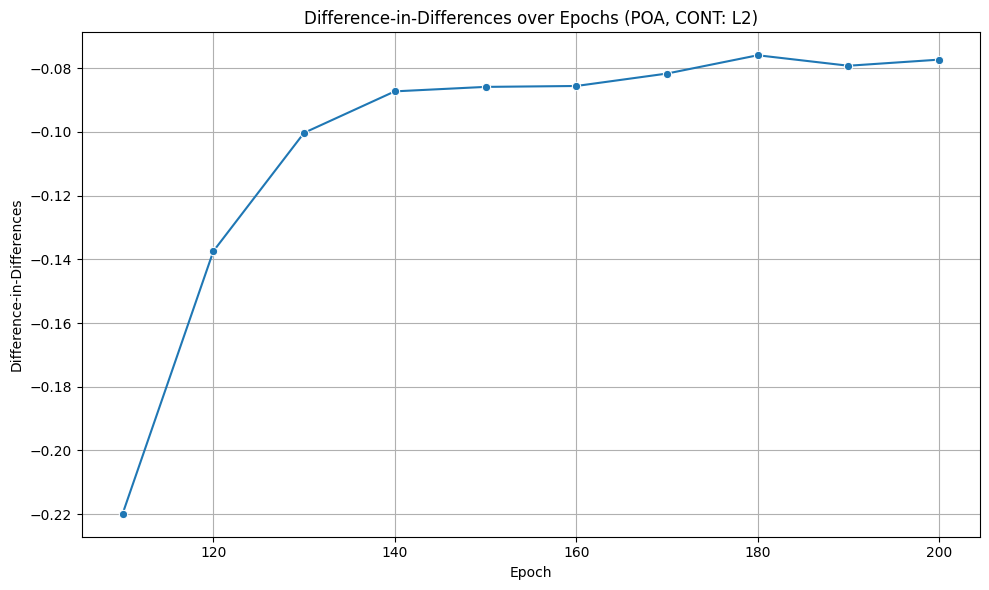

In [23]:
dffindff = []
# draw the epoch-development of the interaction effect
for epoch in range(110, EPOCH_END + 1, 10):
    df_epoch = collected_results_combined
    df_epoch = df_epoch[df_epoch["eval_type"].isin([TYPE_NAME.CONT, TYPE_NAME.POA])]
    # df_epoch = df_epoch[df_epoch["contrast_pair"] == "tsh_ch"]
    df_epoch = df_epoch[df_epoch["eval_lang"] == L_NAME.L2]
    df_epoch = df_epoch[df_epoch["epoch"] == epoch]
    # predicted marginal means
    means = df_epoch.groupby(["recon_class","freeze"])["sil_score"].mean()
    # print(means)
    # difference of differences
    diff = (means["Class","Freeze"] - means["Recon","Freeze"]) - \
        (means["Class","NoFreeze"] - means["Recon","NoFreeze"])

    # print("Difference-in-differences:", diff)
    dffindff.append({"epoch": epoch, "diff_in_diff": diff})

dffindff_df = pd.DataFrame(dffindff)
plt.figure(figsize=(10, 6))
sns.lineplot(data=dffindff_df, x="epoch", y="diff_in_diff", marker="o")
plt.title("Difference-in-Differences over Epochs (POA, CONT: L2)")
plt.xlabel("Epoch")
plt.ylabel("Difference-in-Differences")
plt.grid(True)
plt.tight_layout()
plt.show()

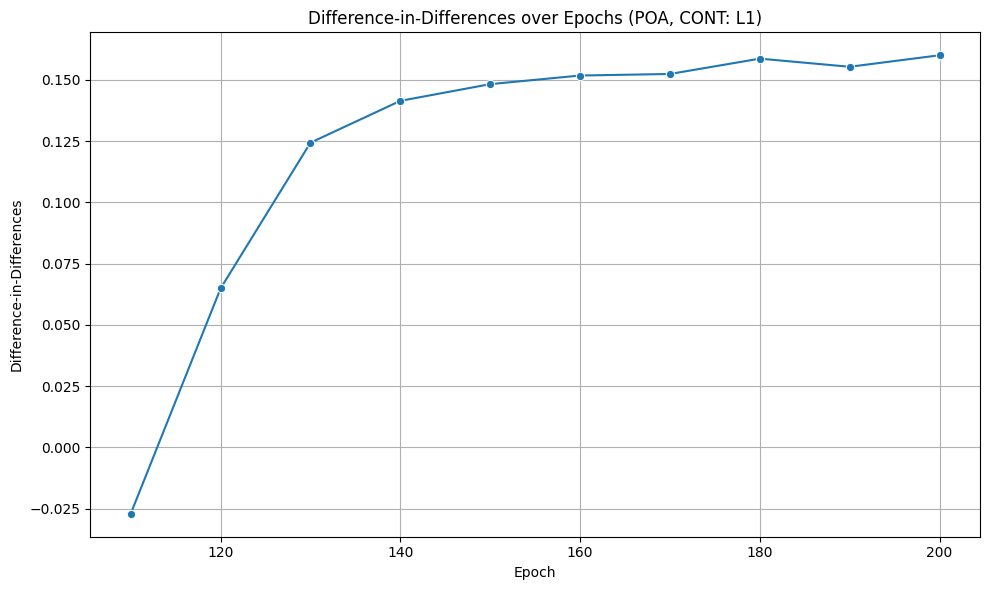

In [18]:
dffindff = []
# draw the epoch-development of the interaction effect
for epoch in range(110, EPOCH_END + 1, 10):
    df_epoch = collected_results_combined
    df_epoch = df_epoch[df_epoch["eval_type"].isin([TYPE_NAME.CONT, TYPE_NAME.POA])]
    df_epoch = df_epoch[df_epoch["eval_lang"] == L_NAME.L1]
    df_epoch = df_epoch[df_epoch["epoch"] == epoch]
    # predicted marginal means
    means = df_epoch.groupby(["recon_class","freeze"])["sil_score"].mean()
    # print(means)
    # difference of differences
    diff = (means["Class","Freeze"] - means["Recon","Freeze"]) - \
        (means["Class","NoFreeze"] - means["Recon","NoFreeze"])

    # print("Difference-in-differences:", diff)
    dffindff.append({"epoch": epoch, "diff_in_diff": diff})

dffindff_df = pd.DataFrame(dffindff)
plt.figure(figsize=(10, 6))
sns.lineplot(data=dffindff_df, x="epoch", y="diff_in_diff", marker="o")
plt.title("Difference-in-Differences over Epochs (POA, CONT: L1)")
plt.xlabel("Epoch")
plt.ylabel("Difference-in-Differences")
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
df = collected_results_combined
df = df[df["eval_type"].isin([TYPE_NAME.CONT, TYPE_NAME.POA])]
df = df[df["epoch"] == 200]
for c in ["eval_lang", "recon_class", "freeze", "run"]:
    df[c] = df[c].astype("category").cat.remove_unused_categories()

df["recon_class"] = df["recon_class"].cat.reorder_categories(
    ["Recon", "Class"], ordered=True
)

df["freeze"] = df["freeze"].cat.reorder_categories(
    ["NoFreeze", "Freeze"], ordered=True
)

cols = ["sil_score","eval_lang","recon_class","freeze","run"]
df = df.dropna(subset=cols)

def fit(formula):
    return smf.mixedlm(formula, df, groups=df["run"]).fit(reml=False)

full = fit("sil_score ~ recon_class * freeze * eval_lang")
full.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                             Mixed Linear Model Regression Results
================================================================================================
Model:                           MixedLM              Dependent Variable:              sil_score
No. Observations:                192                  Method:                          ML       
No. Groups:                      6                    Scale:                           0.0098   
Min. group size:                 32                   Log-Likelihood:                  171.7350 
Max. group size:                 32                   Converged:                       No       
Mean group size:                 32.0                                                           
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              0.554    0.020 27.447 0.000  0.515  0.594
recon_class[T.Class]                                  -0.049    0.029 -1.711 0.087 -0.105  0.007
freeze[T.Freeze]                                       0.017    0.029  0.580 0.562 -0.039  0.073
eval_lang[T.L2]                                        0.016    0.029  0.562 0.574 -0.040  0.072
recon_class[T.Class]:freeze[T.Freeze]                  0.160    0.040  3.962 0.000  0.081  0.239
recon_class[T.Class]:eval_lang[T.L2]                   0.248    0.040  6.143 0.000  0.169  0.327
freeze[T.Freeze]:eval_lang[T.L2]                      -0.003    0.040 -0.083 0.934 -0.083  0.076
recon_class[T.Class]:freeze[T.Freeze]:eval_lang[T.L2] -0.237    0.057 -4.155 0.000 -0.349 -0.125
Group Var                                              0.000                                    
================================================================================================

"""

In [20]:
# from scipy import stats
# df = collected_results_combined
# df = df[df["eval_type"].isin([TYPE_NAME.CONT, TYPE_NAME.POA])]
# df = df[df["epoch"] == 200]
# for c in ["eval_lang", "recon_class", "freeze", "run"]:
#     df[c] = df[c].astype("category").cat.remove_unused_categories()

# cols = ["sil_score","eval_lang","recon_class","freeze","run"]
# df = df.dropna(subset=cols)

# def fit(formula):
#     return smf.mixedlm(formula, df, groups=df["run"]).fit(reml=False)

# full = fit("sil_score ~ recon_class * freeze * eval_lang")
# no_inter = fit("sil_score ~ recon_class + freeze + eval_lang")

# # Likelihood ratio statistic
# lr_stat = 2 * (full.llf - no_inter.llf)

# # degrees of freedom = number of extra parameters (interaction = 1)
# df_diff = full.df_modelwc - no_inter.df_modelwc

# p_value = stats.chi2.sf(lr_stat, df_diff)

# print("LR stat:", lr_stat)
# print("df:", df_diff)
# print("p-value:", p_value)